# 02 · What carries over from one season to the next?

Before asking anything of 43 prospects, it helps to know how the underlying metrics behave across the whole league. For every hitter with 300+ plate appearances in two consecutive seasons (2021→2022 through 2025→2026), this notebook asks two questions:

1. **Stability:** how strongly does each metric repeat from one season to the next?
2. **Forecasting:** does a hitter's plate discipline this season help predict next season's wOBA once his wOBA and xwOBA are known?

The shortened 2020 season is excluded because almost no one reached 300 PA.

In [1]:
import sys
import warnings

warnings.filterwarnings("ignore", message=".*urllib3.*")
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("../outputs/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 3)

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold

from yanks_analytics.data.statcast import CACHE_DIR, load_seasons
from yanks_analytics.features.season import season_table

SEASONS = range(2021, 2027)
MIN_PA = 300

In [2]:
seasons = pd.concat([season_table(load_seasons([season])) for season in SEASONS])
print(f"{len(seasons):,} batter-seasons; {int((seasons['PA'] >= MIN_PA).sum()):,} with {MIN_PA}+ PA")

4,377 batter-seasons; 1,654 with 300+ PA


## Check: do the computed rates match Baseball Savant?

wOBA here follows FanGraphs (reaching on an error earns nothing; season-specific weights), and xwOBA is Savant's expected value per plate appearance. Both are compared with Savant's published expected-statistics leaderboard for qualified hitters.

In [3]:
from pybaseball import statcast_batter_expected_stats

def savant_expected(season: int) -> pd.DataFrame:
    path = CACHE_DIR / f"savant_expected_{season}.parquet"
    if not path.exists():
        statcast_batter_expected_stats(season, minPA=1).to_parquet(path, index=False)
    return pd.read_parquet(path)

rows = []
for season in SEASONS:
    savant = savant_expected(season).rename(columns={"player_id": "batter"}).set_index("batter")
    savant = savant[savant["pa"] >= MIN_PA]
    ours = seasons.xs(season, level="season")
    both = savant[["woba", "est_woba"]].join(ours[["wOBA", "xwOBA"]], how="inner")
    rows.append({
        "season": season, "hitters": len(both),
        "wOBA max |diff|": (both["wOBA"] - both["woba"]).abs().max(),
        "xwOBA max |diff|": (both["xwOBA"] - both["est_woba"]).abs().max(),
        "xwOBA mean |diff|": (both["xwOBA"] - both["est_woba"]).abs().mean(),
    })
check = pd.DataFrame(rows).set_index("season")
check.to_csv(DATA_DIR / "savant_check.csv")
check.style.format("{:.4f}", subset=check.columns[1:])

,hitters,wOBA max |diff|,xwOBA max |diff|,xwOBA mean |diff|
season,,,,
2021,262,0.0005,0.0049,0.0007
2022,277,0.0005,0.0050,0.0009
2023,293,0.0005,0.0043,0.0008
2024,286,0.0005,0.0060,0.0008
2025,277,0.0005,0.0043,0.0008
2026,267,0.0005,0.0092,0.0009


Every qualified hitter's wOBA matches Savant to within .0005, which is Savant's own three-decimal rounding. xwOBA matches closely (mean difference under .001).

## Consecutive-season pairs

In [4]:
METRICS = ["wOBA", "xwOBA", "chase", "chase_breaking", "chase_offspeed", "zone_swing",
           "zone_contact", "whiff", "whiff_96plus", "whiff_breaking", "whiff_two_strike"]

qualified = seasons[seasons["PA"] >= MIN_PA].reset_index()
this_year = qualified.set_index(["batter", "season"])[METRICS + ["PA"]]
next_year = this_year.rename(index=lambda s: s - 1, level="season")
pairs = this_year.join(next_year, rsuffix="_next", how="inner").dropna().reset_index()
print(f"{len(pairs)} season pairs from {pairs['batter'].nunique()} hitters")
print(pairs.groupby("season").size().rename(lambda s: f"{s}->{s + 1}").to_string())

990 season pairs from 391 hitters
season
2021->2022    191
2022->2023    202
2023->2024    205
2024->2025    198
2025->2026    194


## 1. Stability

Year-to-year correlation for each metric, with 95% intervals from a bootstrap that resamples hitters (so a hitter's several pairs move together).

In [5]:
rng = np.random.default_rng(2026)
groups = list(pairs.groupby("batter").indices.values())

def boot_ci(stat, n_boot=2000):
    values = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        values.append(stat(pairs.iloc[np.concatenate([groups[i] for i in pick])]))
    return np.percentile(values, [2.5, 97.5])

rows = []
for m in METRICS:
    r = pairs[m].corr(pairs[f"{m}_next"])
    lo, hi = boot_ci(lambda d, m=m: d[m].corr(d[f"{m}_next"]))
    r_next = pairs[m].corr(pairs["wOBA_next"])
    lo2, hi2 = boot_ci(lambda d, m=m: d[m].corr(d["wOBA_next"]))
    rows.append({"metric": m, "year-to-year r": r, "r 95% CI": f"[{lo:.2f}, {hi:.2f}]",
                 "r with next wOBA": r_next, "next-wOBA 95% CI": f"[{lo2:.2f}, {hi2:.2f}]"})
stability = pd.DataFrame(rows).set_index("metric")
stability.to_csv(DATA_DIR / "metric_stability.csv")
stability.round(2)

,year-to-year r,r 95% CI,r with next wOBA,next-wOBA 95% CI
metric,,,,
wOBA,0.47,"[0.38, 0.54]",0.47,"[0.38, 0.54]"
xwOBA,0.66,"[0.58, 0.72]",0.53,"[0.45, 0.60]"
chase,0.81,"[0.78, 0.84]",-0.18,"[-0.26, -0.10]"
chase_breaking,0.78,"[0.74, 0.81]",-0.12,"[-0.20, -0.03]"
chase_offspeed,0.59,"[0.53, 0.65]",-0.17,"[-0.25, -0.09]"
zone_swing,0.81,"[0.78, 0.84]",0.03,"[-0.06, 0.12]"
zone_contact,0.81,"[0.78, 0.84]",-0.05,"[-0.14, 0.04]"
whiff,0.87,"[0.85, 0.89]",0.02,"[-0.06, 0.11]"
whiff_96plus,0.63,"[0.57, 0.68]",0.03,"[-0.05, 0.10]"


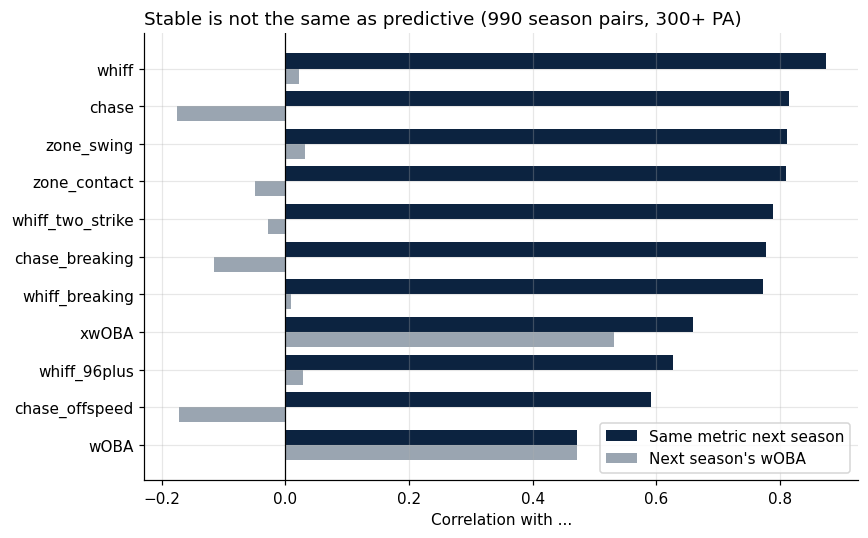

In [6]:
order = stability.sort_values("year-to-year r").index
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(order))
ax.barh(y + 0.2, stability.loc[order, "year-to-year r"], height=0.4, color="#0c2340",
        label="Same metric next season")
ax.barh(y - 0.2, stability.loc[order, "r with next wOBA"], height=0.4, color="#9aa5b1",
        label="Next season's wOBA")
ax.set_yticks(y, order)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with ...")
ax.set_title(f"Stable is not the same as predictive ({len(pairs)} season pairs, {MIN_PA}+ PA)", loc="left")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "stability_vs_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Forecasting next season's wOBA

Linear models scored with 5-fold cross-validation grouped by hitter, so no hitter appears in both the training and test folds. R² is out-of-sample.

In [7]:
DISCIPLINE = ["chase", "chase_breaking", "chase_offspeed", "zone_swing", "zone_contact",
              "whiff", "whiff_96plus", "whiff_breaking", "whiff_two_strike"]
MODELS = {
    "wOBA": ["wOBA"],
    "xwOBA": ["xwOBA"],
    "wOBA + xwOBA": ["wOBA", "xwOBA"],
    "discipline only": DISCIPLINE,
    "wOBA + xwOBA + discipline": ["wOBA", "xwOBA"] + DISCIPLINE,
}

def cv_scores(features):
    X, y = pairs[features].to_numpy(), pairs["wOBA_next"].to_numpy()
    pred = np.empty_like(y)
    for train, test in GroupKFold(n_splits=5).split(X, y, groups=pairs["batter"]):
        pred[test] = LinearRegression().fit(X[train], y[train]).predict(X[test])
    resid = y - pred
    return {"CV R²": 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum(),
            "CV RMSE": np.sqrt((resid ** 2).mean())}

forecast = pd.DataFrame({name: cv_scores(f) for name, f in MODELS.items()}).T
forecast.to_csv(DATA_DIR / "next_season_forecast.csv")
forecast.round(4)

,CV R²,CV RMSE
wOBA,0.217,0.030
xwOBA,0.278,0.029
wOBA + xwOBA,0.278,0.029
discipline only,0.048,0.033
wOBA + xwOBA + discipline,0.271,0.029


## Findings

- **Plate discipline is among the most repeatable things a hitter does.** Whiff rate (r = .87), chase rate, zone swing rate and zone contact rate (all r = .81) repeat far more reliably than wOBA (.47) or xwOBA (.66).
- **That stability does not translate into forecasting power.** Across 990 season pairs, adding nine discipline metrics to wOBA and xwOBA lowers out-of-sample R² slightly (.278 → .271). Discipline alone explains about 5% of next season's wOBA.
- **xwOBA is the better single predictor** of next season's wOBA (CV R² .278 vs .217 for wOBA), consistent with contact quality being more stable than results on balls in play.
- **Chase rate is the one discipline metric with a clear, if small, link to next season's wOBA** (r = −.18). Whiff rates show essentially none, largely because the hardest hitters often swing and miss the most.

**Implication for the prospect questions that follow:** discipline metrics describe a stable approach, but on their own they are weak evidence about future production. Contact quality has to be part of any read.